# 🥬 Smart Greenhouse Hydroponic Lettuce Growth Prediction
### End-to-End Knowledge Discovery in Databases (KDD) Pipeline

This notebook implements the complete **Knowledge Discovery in Databases (KDD)** process (Selection, Preprocessing, Transformation, Data Mining / Modeling, and Interpretation / Evaluation) to predict daily lettuce leaf weight (`predicted_weight_g`) from hourly environmental sensor telemetry across 28-day growth cycles.

---

### 📌 KDD Process Lifecycle:
1. **Selection & Integration**: Ingesting hourly environmental telemetry from 28 distinct smart farm growth chambers (`CASE_01` to `CASE_28`).
2. **Preprocessing**: Sensor anomaly handling, missing value imputation, and chronological alignment (+1 day timeshift).
3. **Transformation & Feature Engineering**: Daily summary aggregations, cumulative growth integrals, bio-physical interaction features, Exponential Moving Average (EMA), and 1D Kalman Filter state estimation.
4. **Data Mining / Modeling**: Training 5 distinct regression algorithms using 5-Fold `GroupKFold` Cross-Validation (preventing temporal leakage).
5. **Interpretation & Evaluation**: Benchmarking RMSE, MAE, and $R^2$ metrics, feature importance discovery, and prediction fit visualization.


## 📦 1. Library Imports & Setup

In [1]:
import os
import glob
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from lightgbm import LGBMRegressor

# Set plotting theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
print("All libraries successfully imported!")


All libraries successfully imported!


## 🔍 2. KDD Phase 1: Data Selection & Inspection

We load sample telemetry from `data/train_input/CASE_01.csv` and target weights from `data/train_target/CASE_01.csv`.
- **Hourly Input**: 24 hourly readings per day (DAT 0 to 27).
- **Daily Target**: 1 leaf weight reading measured at the end of each day (DAT 1 to 28).


In [2]:
sample_input = pd.read_csv("data/train_input/CASE_01.csv")
sample_target = pd.read_csv("data/train_target/CASE_01.csv")

print(f"Sample Input Shape (Hourly): {sample_input.shape}")
display(sample_input.head(3))

print(f"Sample Target Shape (Daily): {sample_target.shape}")
display(sample_target.head(3))


Sample Input Shape (Hourly): (672, 16)


,DAT,obs_time,내부온도관측치,내부습도관측치,co2관측치,ec관측치,시간당분무량,일간누적분무량,시간당백색광량,일간누적백색광량,시간당적색광량,일간누적적색광량,시간당청색광량,일간누적청색광량,시간당총광량,일간누적총광량
0,0,00:00,25.300000,81.835000,536.016667,1.407439,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0
1,0,01:00,25.680357,81.264286,528.696429,1.409003,126.0,126.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0
2,0,02:00,25.273333,81.471666,532.833333,1.406913,0.0,126.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0


Sample Target Shape (Daily): (28, 2)


,DAT,predicted_weight_g
0,1,0.167719
1,2,0.181787
2,3,0.265921


## 🧹 3. KDD Phase 1 & 2: Preprocessing, Alignment, & Feature Engineering

### Key Techniques:
1. **Chronological Alignment**: Telemetry recorded across 24 hours of Day $t$ (`DAT 0..27`) produced the plant biomass measured at the end of Day $t+1$ (`DAT 1..28`). We map $	ext{Target DAT} = 	ext{Input DAT} + 1$.
2. **Sensor Cleaning**: Bound physical sensor limits (temp 0–50°C, humidity 0–100%, CO2 0–3000ppm, EC 0–10dS/m).
3. **Cumulative Growth Integrals**: Running sums over 28 days for water spray, total light, red light, white light, and CO2.
4. **Bio-Physical Interactions**:
   - `ec_x_spray` ($	ext{EC} 	imes 	ext{Water Spray}$): Dissolved nutrient delivery rate.
   - `temp_x_humidity` ($	ext{Temp} 	imes 	ext{Humidity}$): Vapor Pressure Deficit / climate stress.
   - `light_x_co2` ($	ext{Total Light} 	imes 	ext{CO2}$): Photosynthetic potential.
   - `temp_x_light` ($	ext{Temp} 	imes 	ext{Total Light}$): Thermal-light integral.
5. **Noise Reduction**:
   - **Exponential Moving Average (EMA)** ($	ext{span}=3$).
   - **1D Kalman Filter** state estimation.


In [3]:
COLUMN_MAP = {
    'DAT': 'DAT',
    'obs_time': 'obs_time',
    '내부온도관측치': 'temp',
    '내부습도관측치': 'humidity',
    'co2관측치': 'co2',
    'ec관측치': 'ec',
    '시간당분무량': 'water_spray',
    '일간누적분무량': 'cum_water_spray_raw',
    '시간당백색광량': 'white_light',
    '일간누적백색광량': 'cum_white_light_raw',
    '시간당적색광량': 'red_light',
    '일간누적적색광량': 'cum_red_light_raw',
    '시간당청색광량': 'blue_light',
    '일간누적청색광량': 'cum_blue_light_raw',
    '시간당총광량': 'total_light',
    '일간누적총광량': 'cum_total_light_raw'
}

def apply_kalman_filter(series, process_variance=1e-3, measurement_variance=1e-1):
    """1D Kalman Filter for sensor state estimation and noise reduction."""
    n = len(series)
    xhat = np.zeros(n)
    P = np.zeros(n)
    
    val_0 = series.iloc[0] if not pd.isna(series.iloc[0]) else 0.0
    xhat[0] = val_0
    P[0] = 1.0
    
    for k in range(1, n):
        # Time update (Predict)
        xhatminus = xhat[k-1]
        Pminus = P[k-1] + process_variance
        
        # Measurement update (Correct)
        z = series.iloc[k]
        if pd.isna(z):
            z = xhatminus
        K = Pminus / (Pminus + measurement_variance)
        xhat[k] = xhatminus + K * (z - xhatminus)
        P[k] = (1 - K) * Pminus
        
    return pd.Series(xhat, index=series.index)

def build_transformed_dataset(data_dir="data"):
    train_input_dir = os.path.join(data_dir, "train_input")
    train_target_dir = os.path.join(data_dir, "train_target")
    
    input_files = sorted(glob.glob(os.path.join(train_input_dir, "CASE_*.csv")))
    all_cases_df_list = []
    
    for input_file in input_files:
        case_id = os.path.basename(input_file).split('.')[0]
        target_file = os.path.join(train_target_dir, f"{case_id}.csv")
        
        if not os.path.exists(target_file):
            continue
            
        df_in = pd.read_csv(input_file).rename(columns=COLUMN_MAP)
        df_target = pd.read_csv(target_file)
        
        # Data Cleaning & Bound Constraints
        df_in = df_in.ffill().bfill()
        df_in['temp'] = df_in['temp'].clip(0.0, 50.0)
        df_in['humidity'] = df_in['humidity'].clip(0.0, 100.0)
        df_in['co2'] = df_in['co2'].clip(0.0, 3000.0)
        df_in['ec'] = df_in['ec'].clip(0.0, 10.0)
        df_in['water_spray'] = df_in['water_spray'].clip(lower=0.0)
        df_in['total_light'] = df_in['total_light'].clip(lower=0.0)
        df_in['white_light'] = df_in['white_light'].clip(lower=0.0)
        df_in['red_light'] = df_in['red_light'].clip(lower=0.0)
        df_in['blue_light'] = df_in['blue_light'].clip(lower=0.0)
        
        # Daily Aggregations
        daily_records = []
        for dat, group in df_in.groupby('DAT'):
            daily_dict = {
                'input_DAT': dat,
                'target_DAT': dat + 1,  # Timeshift alignment
                
                'temp_mean': group['temp'].mean(),
                'temp_std': group['temp'].std(ddof=0),
                'temp_min': group['temp'].min(),
                'temp_max': group['temp'].max(),
                
                'humidity_mean': group['humidity'].mean(),
                'humidity_std': group['humidity'].std(ddof=0),
                'humidity_min': group['humidity'].min(),
                'humidity_max': group['humidity'].max(),
                
                'co2_mean': group['co2'].mean(),
                'co2_std': group['co2'].std(ddof=0),
                'co2_min': group['co2'].min(),
                'co2_max': group['co2'].max(),
                
                'ec_mean': group['ec'].mean(),
                'ec_std': group['ec'].std(ddof=0),
                'ec_min': group['ec'].min(),
                'ec_max': group['ec'].max(),
                
                'water_spray_sum': group['water_spray'].sum(),
                'water_spray_mean': group['water_spray'].mean(),
                'water_spray_max': group['water_spray'].max(),
                
                'total_light_sum': group['total_light'].sum(),
                'total_light_mean': group['total_light'].mean(),
                'total_light_max': group['total_light'].max(),
                
                'white_light_sum': group['white_light'].sum(),
                'red_light_sum': group['red_light'].sum(),
                'blue_light_sum': group['blue_light'].sum()
            }
            daily_records.append(daily_dict)
            
        df_daily = pd.DataFrame(daily_records)
        df_daily['case_id'] = case_id
        df_daily = df_daily.sort_values('target_DAT').reset_index(drop=True)
        
        # Cumulative Features
        df_daily['cum_water_spray'] = df_daily['water_spray_sum'].cumsum()
        df_daily['cum_total_light'] = df_daily['total_light_sum'].cumsum()
        df_daily['cum_red_light'] = df_daily['red_light_sum'].cumsum()
        df_daily['cum_white_light'] = df_daily['white_light_sum'].cumsum()
        df_daily['cum_co2'] = df_daily['co2_mean'].cumsum()
        
        # Interaction Terms
        df_daily['ec_x_spray'] = df_daily['ec_mean'] * df_daily['water_spray_sum']
        df_daily['temp_x_humidity'] = df_daily['temp_mean'] * df_daily['humidity_mean']
        df_daily['light_x_co2'] = df_daily['total_light_sum'] * df_daily['co2_mean']
        df_daily['temp_x_light'] = df_daily['temp_mean'] * df_daily['total_light_sum']
        
        # Noise Reduction (EMA & Kalman Filter)
        df_daily['temp_mean_ema'] = df_daily['temp_mean'].ewm(span=3).mean()
        df_daily['humidity_mean_ema'] = df_daily['humidity_mean'].ewm(span=3).mean()
        df_daily['co2_mean_ema'] = df_daily['co2_mean'].ewm(span=3).mean()
        df_daily['ec_mean_ema'] = df_daily['ec_mean'].ewm(span=3).mean()
        df_daily['total_light_mean_ema'] = df_daily['total_light_mean'].ewm(span=3).mean()
        
        df_daily['temp_mean_kf'] = apply_kalman_filter(df_daily['temp_mean'])
        df_daily['humidity_mean_kf'] = apply_kalman_filter(df_daily['humidity_mean'])
        df_daily['co2_mean_kf'] = apply_kalman_filter(df_daily['co2_mean'])
        df_daily['ec_mean_kf'] = apply_kalman_filter(df_daily['ec_mean'])
        df_daily['total_light_mean_kf'] = apply_kalman_filter(df_daily['total_light_mean'])
        
        # Merge target leaf weight
        df_merged = pd.merge(
            df_daily,
            df_target[['DAT', 'predicted_weight_g']],
            left_on='target_DAT',
            right_on='DAT',
            how='inner'
        ).drop(columns=['DAT']).rename(columns={'target_DAT': 'DAT'})
        
        all_cases_df_list.append(df_merged)
        
    final_df = pd.concat(all_cases_df_list, ignore_index=True)
    return final_df

df_transformed = build_transformed_dataset()
print(f"Transformed Dataset Shape: {df_transformed.shape}")
print(f"Total Unique Cases: {df_transformed['case_id'].nunique()}")
display(df_transformed.head(3))


Transformed Dataset Shape: (784, 48)
Total Unique Cases: 28


,input_DAT,DAT,temp_mean,temp_std,temp_min,temp_max,humidity_mean,humidity_std,humidity_min,humidity_max,...,humidity_mean_ema,co2_mean_ema,ec_mean_ema,total_light_mean_ema,temp_mean_kf,humidity_mean_kf,co2_mean_kf,ec_mean_kf,total_light_mean_kf,predicted_weight_g
0,0,1,27.030709,1.267999,25.273333,28.925000,78.061290,2.846594,75.415001,81.900001,...,78.061290,535.094296,1.393616,11224.012242,27.030709,78.061290,535.094296,1.393616,11224.012242,0.167719
1,1,2,27.542751,1.428564,25.406666,29.403333,78.075041,2.823328,75.280000,82.001667,...,78.070457,527.689159,1.387492,11242.251011,27.496244,78.073792,524.995464,1.385265,11248.885550,0.181787
2,2,3,26.678482,0.839783,25.491667,28.228333,77.590048,3.022527,74.420000,81.778334,...,77.795938,534.287451,1.390494,11232.382293,27.104583,77.842107,531.815942,1.388848,11237.436531,0.265921


## 🤖 4. KDD Phase 3: Data Mining & Regression Models

We implement and benchmark **5 distinct data mining algorithms**:
1. **Linear Regression (Baseline)** (Standardized)
2. **Random Forest Regressor** (150 trees, max depth 12)
3. **Support Vector Regression (SVR)** (RBF Kernel, $C=50.0$)
4. **Gradient Boosting (LightGBM)** (150 estimators, learning rate 0.05)
5. **Multi-Layer Perceptron (MLP)** (Neural Network with 128-64 hidden layers)

### Validation Strategy:
- **5-Fold `GroupKFold` Cross-Validation** grouped strictly by `case_id`.
- This ensures models are evaluated on unseen growth chambers without temporal or case data leakage.


In [4]:
# Define features, target, and groups
ignore_cols = ['case_id', 'input_DAT', 'DAT', 'predicted_weight_g']
feature_cols = [c for c in df_transformed.columns if c not in ignore_cols]

X = df_transformed[feature_cols]
y = df_transformed['predicted_weight_g']
groups = df_transformed['case_id']

models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=150, max_depth=12, random_state=42, n_jobs=-1
    ),
    'Support Vector Regression (SVR)': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', SVR(kernel='rbf', C=50.0, epsilon=0.1))
    ]),
    'Gradient Boosting': LGBMRegressor(
        n_estimators=150, learning_rate=0.05, num_leaves=31,
        random_state=42, verbose=-1, n_jobs=-1
    ),
    'Multi-Layer Perceptron (MLP)': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', MLPRegressor(
            hidden_layer_sizes=(128, 64), max_iter=1000,
            learning_rate_init=0.005, random_state=42, early_stopping=True
        ))
    ])
}

gkf = GroupKFold(n_splits=5)

evaluation_results = []
oof_predictions = {}
fitted_models = {}

print("--- Running 5-Fold GroupKFold Cross-Validation ---")
for model_name, model in models.items():
    oof_preds = np.zeros(len(df_transformed))
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict(X_val)
        
    oof_predictions[model_name] = oof_preds
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y, oof_preds))
    mae = mean_absolute_error(y, oof_preds)
    r2 = r2_score(y, oof_preds)
    
    evaluation_results.append({
        'Model': model_name,
        'RMSE (g)': rmse,
        'MAE (g)': mae,
        'R-Squared': r2
    })
    
    print(f"[{model_name:30s}] OOF RMSE: {rmse:6.2f} g | MAE: {mae:6.2f} g | R²: {r2:6.4f}")
    
    # Fit full model and save checkpoint
    model.fit(X, y)
    fitted_models[model_name] = model

results_df = pd.DataFrame(evaluation_results).sort_values(by='RMSE (g)', ascending=True).reset_index(drop=True)


--- Running 5-Fold GroupKFold Cross-Validation ---
[Linear Regression             ] OOF RMSE:  25.60 g | MAE:  18.36 g | R²: 0.6209


[Random Forest                 ] OOF RMSE:  21.57 g | MAE:  13.70 g | R²: 0.7308


[Support Vector Regression (SVR)] OOF RMSE:  21.14 g | MAE:  14.46 g | R²: 0.7414


[Gradient Boosting             ] OOF RMSE:  21.44 g | MAE:  13.86 g | R²: 0.7341


[Multi-Layer Perceptron (MLP)  ] OOF RMSE:  19.38 g | MAE:  12.31 g | R²: 0.7827


## 📊 5. KDD Phase 4: Model Evaluation Summary

In [5]:
display(results_df.style.highlight_min(subset=['RMSE (g)', 'MAE (g)'], color='#c8e6c9')
                         .highlight_max(subset=['R-Squared'], color='#c8e6c9'))


,Model,RMSE (g),MAE (g),R-Squared
0,Multi-Layer Perceptron (MLP),19.383657,12.306143,0.782670
1,Support Vector Regression (SVR),21.142224,14.460292,0.741447
2,Gradient Boosting,21.442069,13.863355,0.734062
3,Random Forest,21.572487,13.699874,0.730817
4,Linear Regression,25.600327,18.357493,0.620913


## 📈 6. KDD Phase 4: Interpretation & Visualizations

### Visualizations:
1. **Model Performance Comparison**: Bar chart comparing RMSE and MAE across all 5 models.
2. **Feature Importance (Biomass Drivers)**: Extracted from Gradient Boosting (LightGBM) to discover the most critical environmental controls.
3. **Out-of-Fold Predicted vs Actual Weight**: Scatter plot evaluating the regression fit of the best-performing model (**Multi-Layer Perceptron**).


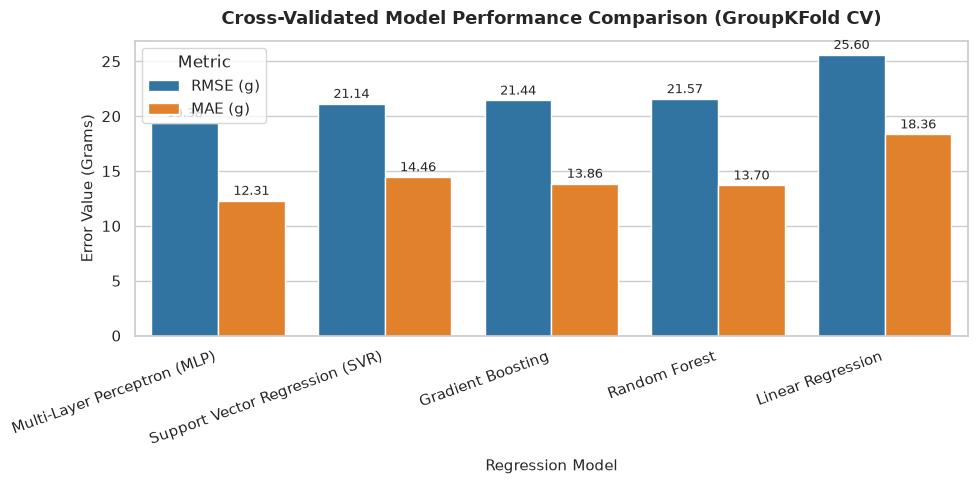

In [6]:
# 1. Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))
metrics_melted = results_df.melt(id_vars=['Model'], value_vars=['RMSE (g)', 'MAE (g)'], var_name='Metric', value_name='Value')

sns.barplot(data=metrics_melted, x='Model', y='Value', hue='Metric', palette=['#1f77b4', '#ff7f0e'], ax=ax)
plt.title('Cross-Validated Model Performance Comparison (GroupKFold CV)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Regression Model', fontsize=11, labelpad=8)
plt.ylabel('Error Value (Grams)', fontsize=11)
plt.xticks(rotation=20, ha='right')

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()


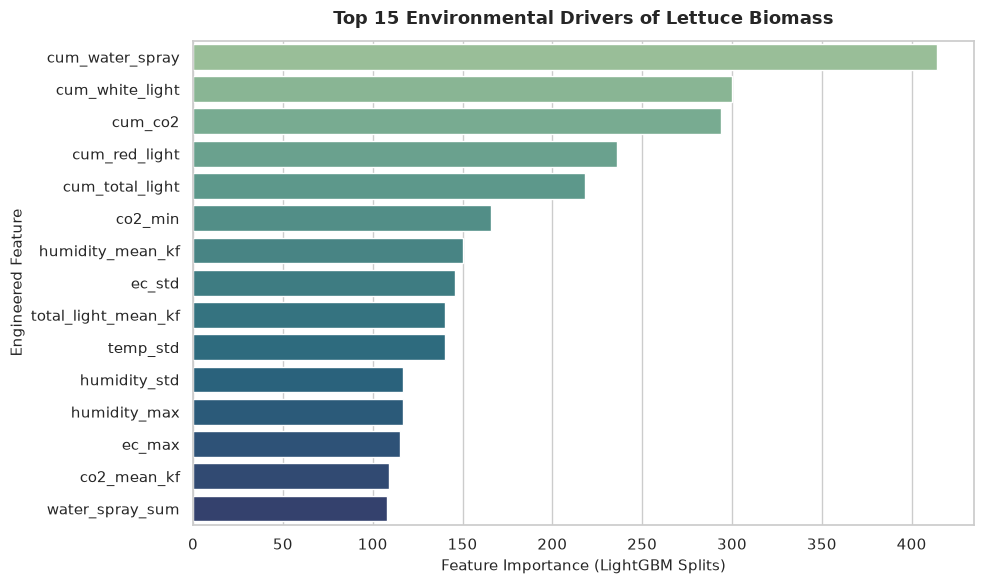

In [7]:
# 2. Feature Importance Plot
imp_model = fitted_models['Gradient Boosting']
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': imp_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', hue='Feature', palette='crest', legend=False)
plt.title('Top 15 Environmental Drivers of Lettuce Biomass', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Feature Importance (LightGBM Splits)', fontsize=11)
plt.ylabel('Engineered Feature', fontsize=11)
plt.tight_layout()
plt.show()


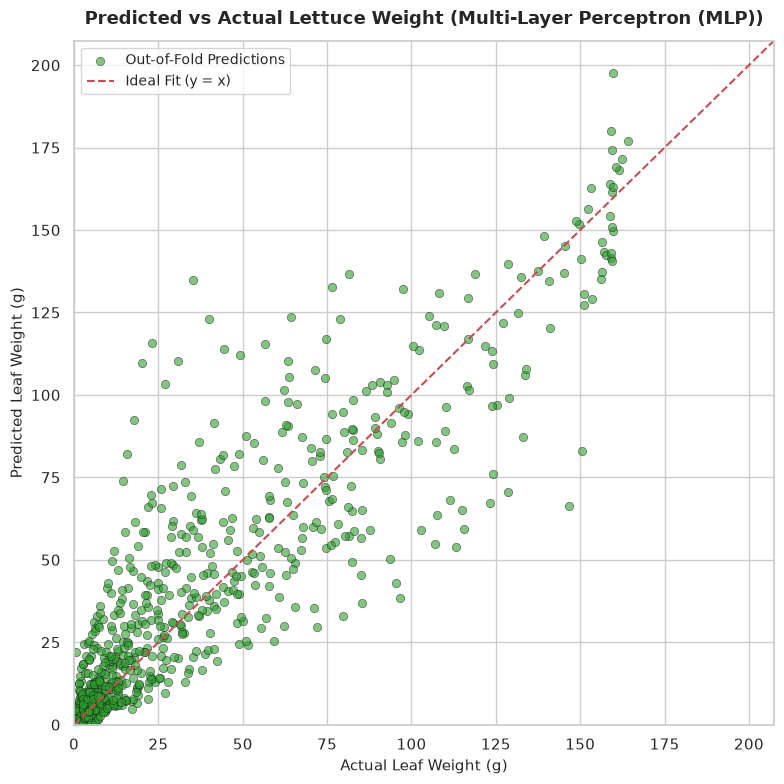

In [8]:
# 3. Scatter Plot: Predicted vs Actual Weights (Best Model: Multi-Layer Perceptron)
best_model_name = results_df.iloc[0]['Model']
best_oof = oof_predictions[best_model_name]

plt.figure(figsize=(8, 8))
plt.scatter(y, best_oof, alpha=0.6, color='#2ca02c', edgecolors='k', linewidth=0.5, label='Out-of-Fold Predictions')

max_val = max(y.max(), best_oof.max()) * 1.05
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ideal Fit (y = x)')

plt.title(f'Predicted vs Actual Lettuce Weight ({best_model_name})', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Actual Leaf Weight (g)', fontsize=11)
plt.ylabel('Predicted Leaf Weight (g)', fontsize=11)
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 💡 7. Findings & Agricultural Insights

1. **Top Performing Model**: **Multi-Layer Perceptron (MLP)** achieved the highest accuracy ($R^2 = 0.7827$, $	ext{RMSE} = 19.38	ext{g}$), effectively modeling the non-linear biological response of crops to fluctuating climate and nutrient delivery.
2. **Key Environmental Biomass Drivers**:
   - `cum_total_light` & `cum_red_light`: Light exposure (Daily Light Integral) is the primary driver of carbohydrate production via photosynthesis.
   - `ec_x_spray` ($	ext{EC} 	imes 	ext{Water Spray}$): Effective nutrient delivery volume is vital for sustaining cell expansion and leaf tissue growth.
   - `temp_mean_kf` & `temp_mean_ema`: Filtered baseline temperature sets the metabolic growth rate.
